In [2]:
# idk this will do stuff
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob
from aqa_parsing_utilities import *
from data_center_model import *
from training_utilities import *
from sklearn.preprocessing import normalize
from torch.utils.data import DataLoader


In [3]:
# testing new dataloader
dc_dataset = DCDataset()
print(dc_dataset.__len__())
dc_dataset.get_statistics()

80809
*** Datacenter Dataset Statistics ***
** Cost Statistics ** 
Average Cost Power: 10.714332580566406
Average Cost Error: 10.30894947052002
Average Cost QoS: 11.753349304199219


In [15]:
data_file_path = '../data/all_data.csv'
csv = pd.read_csv(data_file_path)
len = csv.shape[0]
use_norm_cost = True
use_norm_pr = True

### Cost - our labels!
c_power,c_error,c_qos = np.array(list(csv['cost_power'].values)),np.array(list(csv['cost_error'].values)),np.array(list(csv['cost_qos']))
if use_norm_cost:
    server_counts = np.array(list(csv['client_count'].values))
    job_mix_length = np.array(list(csv['workload_mix_size']))
    c_power_norm,c_error_norm,c_qos_norm = c_power/server_counts,c_error/server_counts,c_qos/job_mix_length
costs = np.zeros((len,3))
costs[:,0],costs[:,1],costs[:,2] = c_power,c_error,c_qos

### Our tabular server features
p_norm,r_norm = np.array(list(csv['p_norm'].values)),np.array(list(csv['r_norm'].values))
p,r = np.array(list(csv['p'].values))/1000,np.array(list(csv['r'].values))/1000
p_server_norm,r_server_norm = np.array(list(csv['p'].values))/(server_counts*1000),np.array(list(csv['r'].values))/(server_counts*1000)
client_count,util,wload_size = list(csv['client_count'].values),list(csv['util'].values),list(csv['workload_mix_size'])

Text(0.5, 1.0, 'p server Norm Histogram')

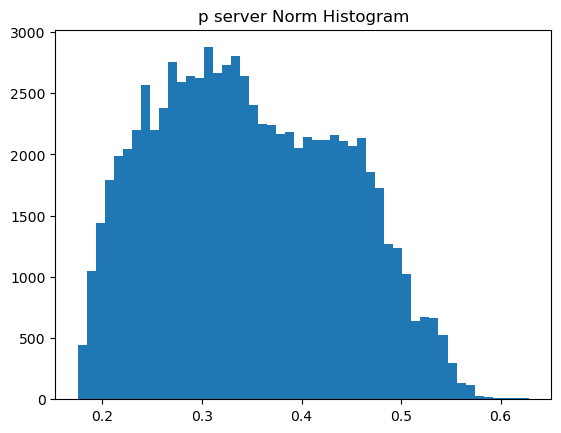

In [17]:
plt.hist(p_server_norm,bins=50)
plt.title('p server Norm Histogram')

Text(0.5, 1.0, 'r Server Norm Histogram')

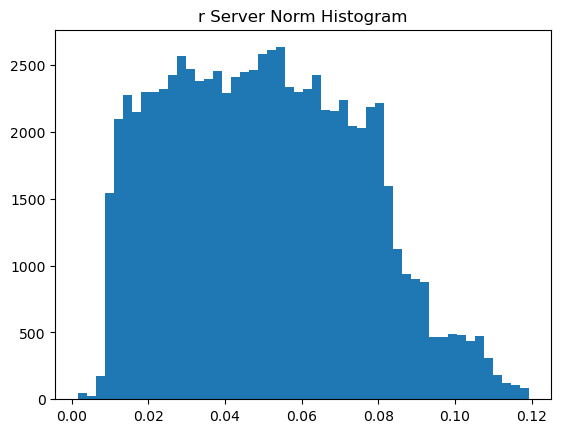

In [18]:
plt.hist(r_server_norm,bins=50)
plt.title('r Server Norm Histogram')

Text(0.5, 1.0, 'p Histogram')

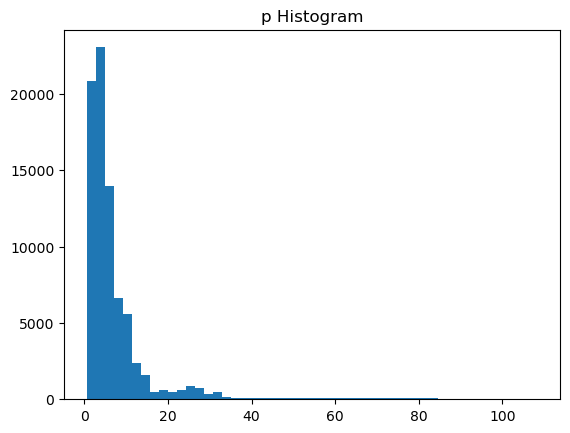

In [14]:
plt.hist(r,bins=50)
plt.title('p Histogram')

Text(0.5, 1.0, 'Cost Power Histogram')

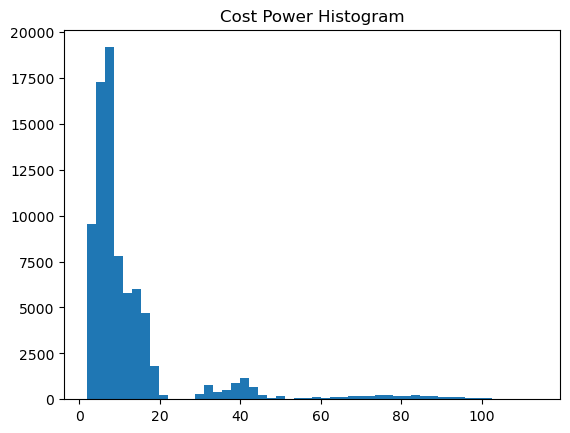

In [28]:
plt.hist(c_power,bins=50)
plt.title('Cost Power Histogram')

Text(0.5, 1.0, 'Normalized Cost Power Histogram')

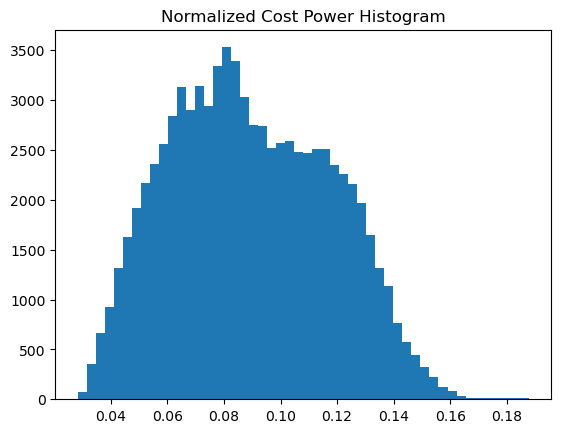

In [29]:
plt.hist(c_power_norm,bins=50)
plt.title('Normalized Cost Power Histogram')

Text(0.5, 1.0, 'Cost Error Histogram')

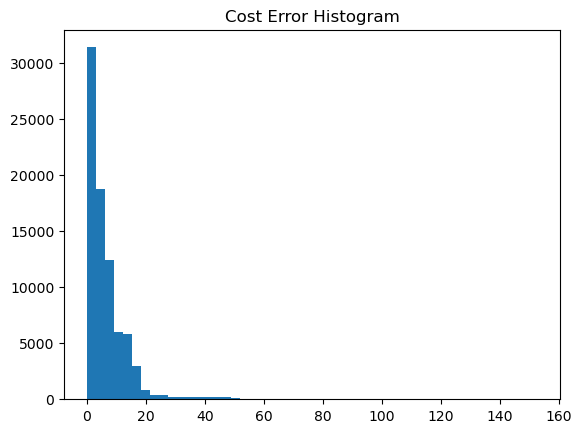

In [27]:
plt.hist(c_error,bins=50)
plt.title('Cost Error Histogram')

Text(0.5, 1.0, 'NormalizedCost Error Histogram')

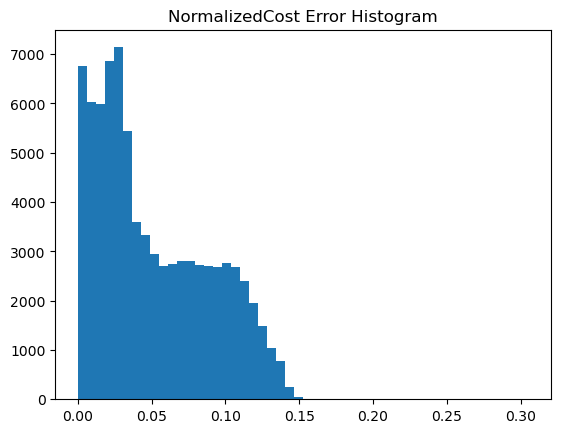

In [26]:
plt.hist(c_error_norm,bins=50)
plt.title('NormalizedCost Error Histogram')

Text(0.5, 1.0, 'QoS Cost Histogram')

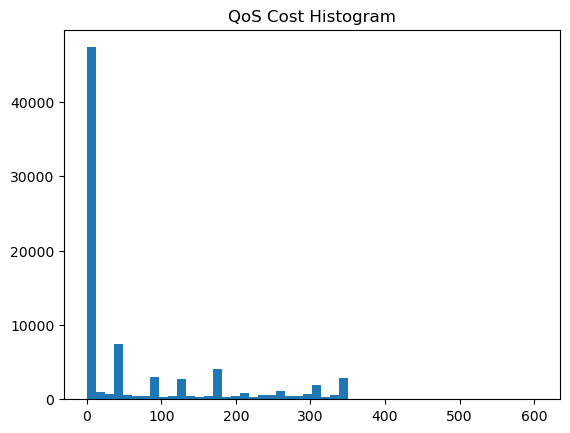

In [33]:
plt.hist(c_qos,bins=50)
plt.title('QoS Cost Histogram')

Text(0.5, 1.0, 'Normalized QoS Cost Histogram')

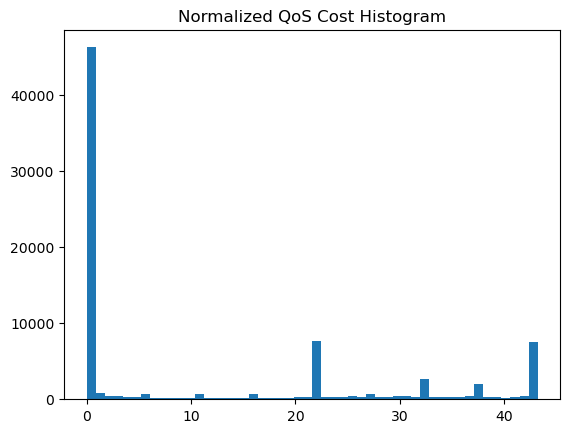

In [35]:
plt.hist(c_qos_norm,bins=50)
plt.title('Normalized QoS Cost Histogram')